## **Project Overview**

This project will conduct an in-depth Exploratory Data Analysis (EDA) on a Home Loan dataset. The objective is to understand the underlying structure, trends, and relationships in the data through data cleaning, visualization, and statistical analysis. This initial investigation is essential for uncovering patterns that may influence loan approvals and risk assessment.

Financial institutions rely on historical loan data to assess creditworthiness and refine their lending practices. The Home Loan dataset contains key information on applicants, such as income, employment status, credit history, and property details, along with the corresponding loan outcomes. By performing a comprehensive EDA, one can reveal critical insights into factors that affect loan approvals, defaults, and overall financial risk, which is instrumental for data-driven decision making in the mortgage industry.

The primary goal of this project is to perform a thorough exploratory analysis of the Home Loan dataset.

### **Data Collection and Preparation**

In [13]:
# Importing the necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import os

##### **Loading datasets directly from Github into a Pandas DataFrame**

In [14]:
url = r"https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/home_loan_train.csv"

data = pd.read_csv(url)

# Saving & Loading the dataset locally.
data.to_csv(r"Home_loan", index=False)

In [15]:
df = pd.read_csv(r"Home_loan")


After loading, the next thing to do is get a preview of the dataset.

In [16]:
df.head(17)       # See the first 5 rows

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


In [17]:
df.shape        # Number of rows and columns

(614, 13)

In [18]:
df.info()   # Column names, data types, non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


#### **Inspecting for missing values, duplicates, and data type inconsistencies**

In [19]:
# Checking missing values
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [20]:
# Checking for duplicates values
df.duplicated().sum()

np.int64(0)

No duplicate values in the data frame.

In [21]:
# Checking for data inconsistencies
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [22]:
df["Dependents"] = df["Dependents"].replace("3+", 3)
df[["Dependents", "ApplicantIncome"]].astype("float16")

c:\Users\ncc\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\ncc\AppData\Local\Programs\Python\Python314\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,Dependents,ApplicantIncome
0,0.0,5848.0
1,1.0,4584.0
2,0.0,3000.0
3,0.0,2584.0
4,0.0,6000.0
...,...,...
609,0.0,2900.0
610,3.0,4104.0
611,1.0,8072.0
612,2.0,7584.0


In [23]:
df.head(7)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


#### **Cleaning the dataset**

In [24]:
# Making a copy of our data
data = df.copy()

In [25]:
# Fill missing values in all non-numerical columns with their respective modes.
mode_gender = data["Gender"].mode()[0]        # This will return the highest occurrences values therein.
data["Gender"].fillna(mode_gender, inplace=True)

mode_married = data["Married"].mode()[0]
data["Married"].fillna(mode_married, inplace=True)

mode_dependents = data["Dependents"].mode()[0]
data["Dependents"].fillna(mode_dependents, inplace=True)

mode_employed = data["Self_Employed"].mode()[0]
data["Self_Employed"].fillna(mode_employed, inplace=True)

mode_loan = data["Loan_Status"].mode()[0]
data["Loan_Status"].fillna(mode_loan, inplace=True)



In [26]:
# Fill missing values in all numerical columns with their respective medians
data.fillna(data.median(numeric_only=True), inplace=True)

In [27]:
data.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### **Exploratory Data Analysis (EDA)**

**Performing descriptive statistics to summarize the key characteristics of the data.**

In [28]:
# Descriptive Statistics of the data
data.head(3)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [29]:
# Setting Loan_ID as index
data.set_index("Loan_ID", inplace=True)

In [30]:
data.head(3)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [31]:
# Picking out the numerical columns and get the descriptions
# numerical_features = data.select_dtypes(include=['float64', 'int64']).columns
numerical_features = data.select_dtypes(include='number').columns
data[numerical_features].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.459283,6109.041673,150.0,2877.50,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.245798,2926.248369,0.0,0.00,1188.5,2297.25,41667.0
LoanAmount,614.0,145.752443,84.107233,9.0,100.25,128.0,164.75,700.0
Loan_Amount_Term,614.0,342.410423,64.428629,12.0,360.00,360.0,360.00,480.0
Credit_History,614.0,0.855049,0.352339,0.0,1.00,1.0,1.00,1.0


In [32]:
# Checking the number of loan applicants by gender
pd.DataFrame(data["Gender"].value_counts())

,count
Gender,
Male,502
Female,112


In [33]:
# Checking the number of loan applicants by Education
pd.DataFrame(data["Education"].value_counts())

,count
Education,
Graduate,480
Not Graduate,134


In [34]:
# Checking the number of loan applicants by Property area
pd.DataFrame(data["Property_Area"].value_counts())

,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


**Visualize distributions of numerical features (e.g., applicant income, loan amount) using histograms and box plots.**

In [35]:
data.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

### **Univariate Analysis**

In [36]:
# Performing Univariate Analysis
def univariate_numerical_eda(data, column):
    """
    Performs univariate EDA on a single numerical column
    displays summary statistics, skewness, kurtosis, histogram, KDE, and boxplot.
    """
    print(f"Feature: {column}")
    print("*"*40)
    print(data[column].describe().to_frame())
    print(f"Skweness: {data[column].skew():.3f}")
    print(f"Kurtosis: {df[column].kurt():.3f}")

    plt.figure(figsize=(12,4))

    # Histogram + KDE
    plt.subplot(1,2,1)
    sns.histplot(df[column], kde=True, bins=30, color='teal')
    plt.title(f'\n Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[column], color='teal')
    plt.title(f'\n Boxplot of {column}', fontsize=13)

    plt.tight_layout()
    plt.show()

    # Optional note on transformation
    if abs(df[column].skew()) > 1:
        print(f"\n {column} is highly skewed. Consider log or Box-Cox transformation.")
    elif abs(df[column].skew()) > 0.5:
        print(f"{column} is moderately skewed.")
    else:
        print(f"{column} is fairly symmetric.")

Feature: ApplicantIncome
****************************************
       ApplicantIncome
count       614.000000
mean       5403.459283
std        6109.041673
min         150.000000
25%        2877.500000
50%        3812.500000
75%        5795.000000
max       81000.000000
Skweness: 6.540
Kurtosis: 60.541


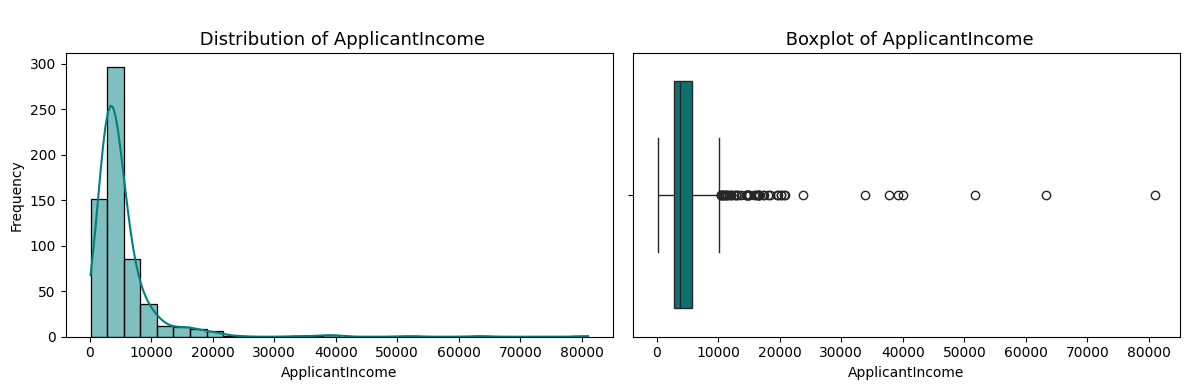


 ApplicantIncome is highly skewed. Consider log or Box-Cox transformation.
Feature: CoapplicantIncome
****************************************
       CoapplicantIncome
count         614.000000
mean         1621.245798
std          2926.248369
min             0.000000
25%             0.000000
50%          1188.500000
75%          2297.250000
max         41667.000000
Skweness: 7.492
Kurtosis: 84.956


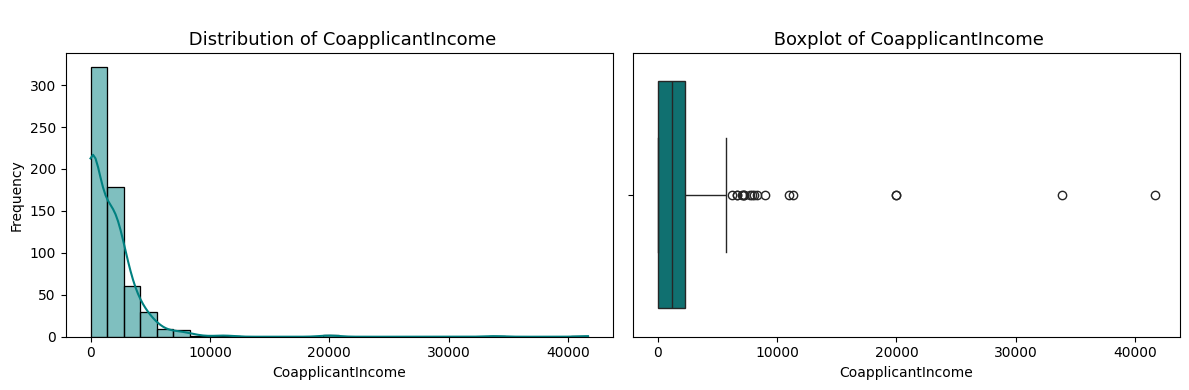


 CoapplicantIncome is highly skewed. Consider log or Box-Cox transformation.
Feature: LoanAmount
****************************************
       LoanAmount
count  614.000000
mean   145.752443
std     84.107233
min      9.000000
25%    100.250000
50%    128.000000
75%    164.750000
max    700.000000
Skweness: 2.743
Kurtosis: 10.402


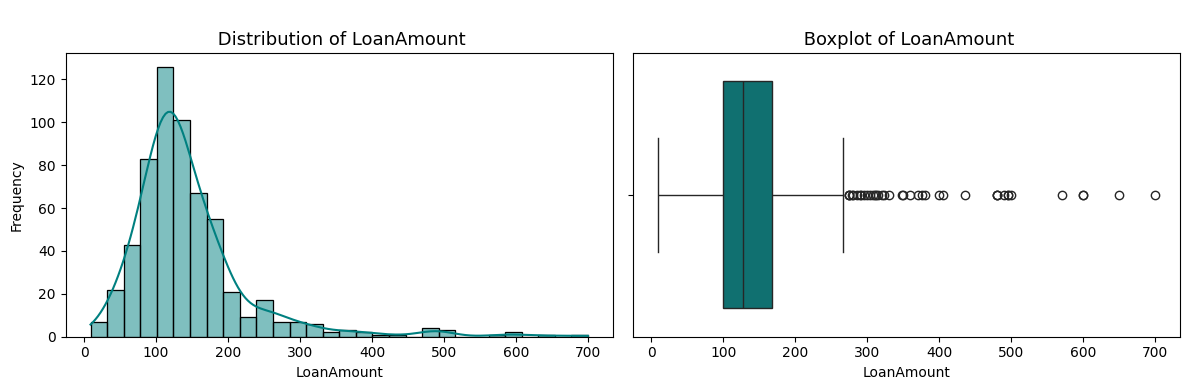


 LoanAmount is highly skewed. Consider log or Box-Cox transformation.
Feature: Loan_Amount_Term
****************************************
       Loan_Amount_Term
count        614.000000
mean         342.410423
std           64.428629
min           12.000000
25%          360.000000
50%          360.000000
75%          360.000000
max          480.000000
Skweness: -2.402
Kurtosis: 6.673


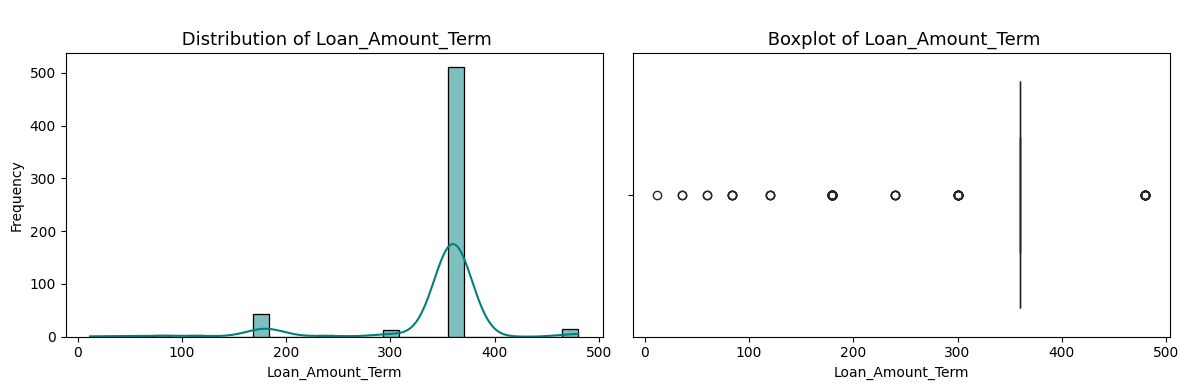


 Loan_Amount_Term is highly skewed. Consider log or Box-Cox transformation.
Feature: Credit_History
****************************************
       Credit_History
count      614.000000
mean         0.855049
std          0.352339
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Skweness: -2.022
Kurtosis: 1.549


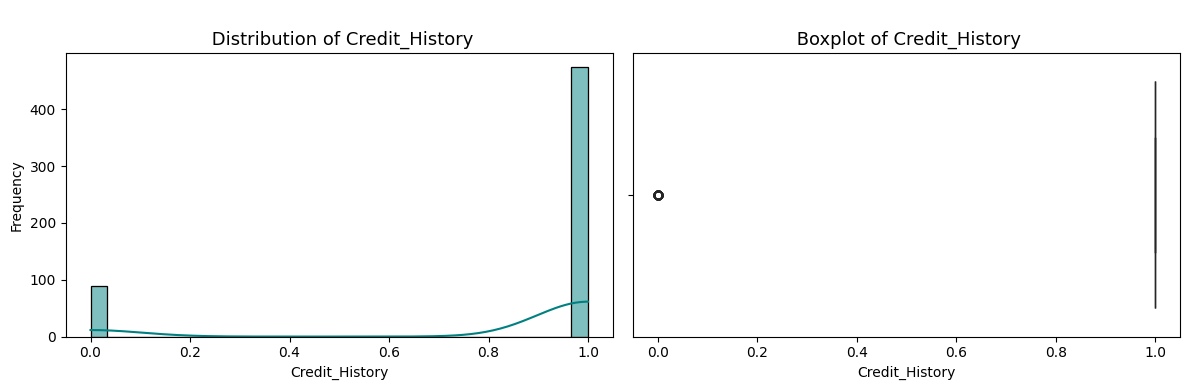


 Credit_History is highly skewed. Consider log or Box-Cox transformation.


In [37]:
# So, Looping through all the columns to save Time
for col in numerical_features:
    univariate_numerical_eda(data, col)

**Analyze categorical features (e.g., education, employment status, property area) using bar charts and pie charts.**

In [38]:
def univariate_categorical_eda(data, column):
    """
    Performs univariate EDA on a categorical or ordinal column.
    Displays frequency table, proportion, and a countplot.
    """
    print(f"Feature: {column}")
    print("*"*40)

    # Frequency + proportion
    freq = data[column].value_counts()
    prop = data[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': freq, 'Percentage': prop.round(2)})
    print(summary)
    print()

    # Visualization
    plt.figure(figsize=(12,4))

    # Bar chart
    plt.subplot(1,2,1)
    ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')
    plt.title(f'Distribution of {column}', fontsize=13)
    plt.xlabel(column)
    plt.ylabel('Count')

    # Annotate each bar with percentage
    total = len(data[column])
    for p in ax.patches:
        height = p.get_height()
        ax.text(p.get_x() + p.get_width()/2, height + 1,
                f'{(height/total)*100:.1f}%', ha='center')

    # Piechart
    plt.subplot(1,2,2)
    plt.pie(freq, labels=freq.index, autopct="%1.1f%%")

    plt.tight_layout()
    plt.show()

In [39]:
categorical_columns = data.select_dtypes(include="object").columns
categorical_columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area', 'Loan_Status'],
      dtype='object')

Feature: Gender
****************************************
        Count  Percentage
Gender                   
Male      502       81.76
Female    112       18.24



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


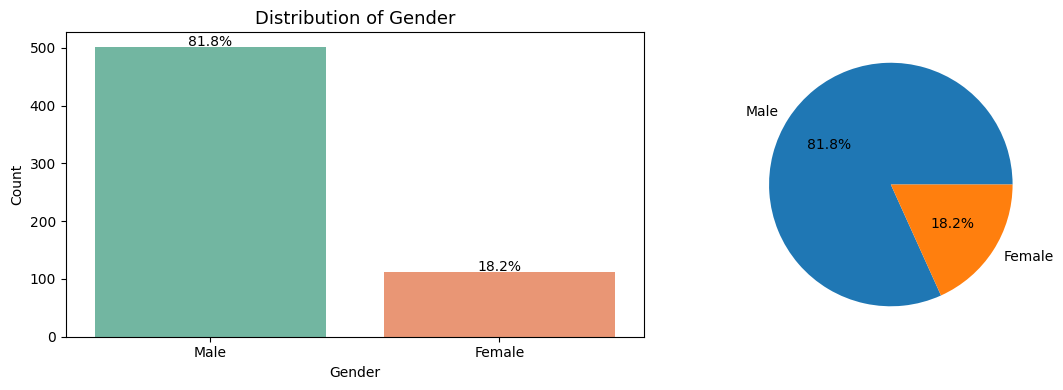

Feature: Married
****************************************
         Count  Percentage
Married                   
Yes        401       65.31
No         213       34.69



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


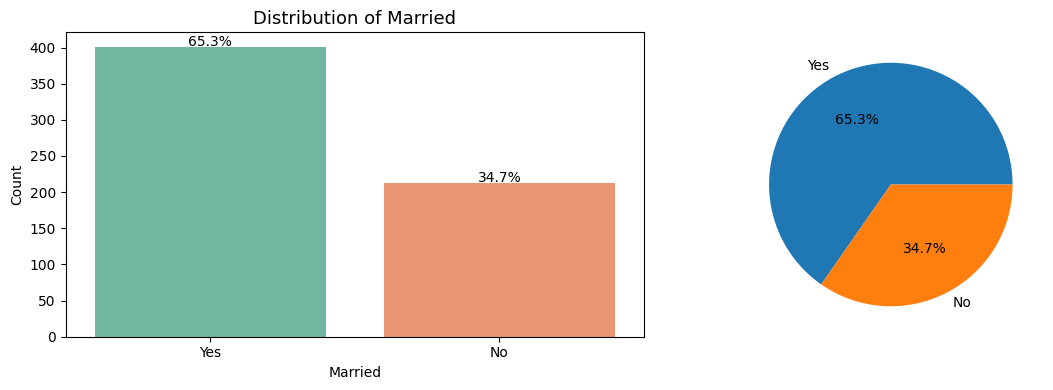

Feature: Dependents
****************************************
            Count  Percentage
Dependents                   
0             360       58.63
1             102       16.61
2             101       16.45
3              51        8.31



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


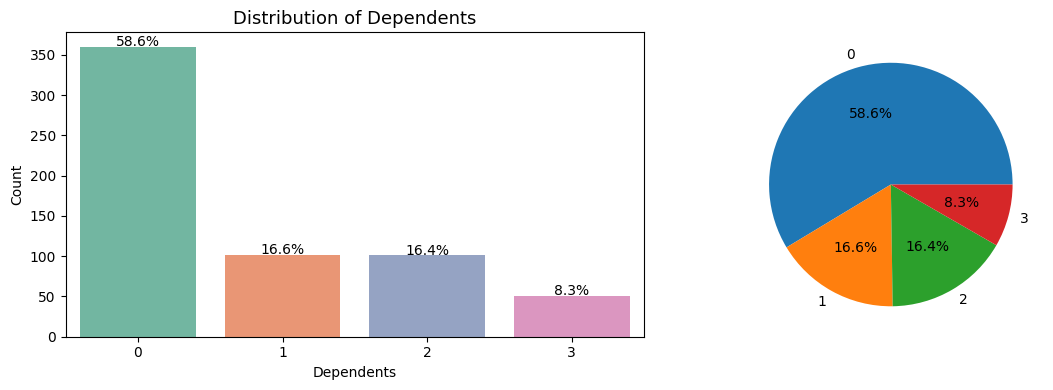

Feature: Education
****************************************
              Count  Percentage
Education                      
Graduate        480       78.18
Not Graduate    134       21.82



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


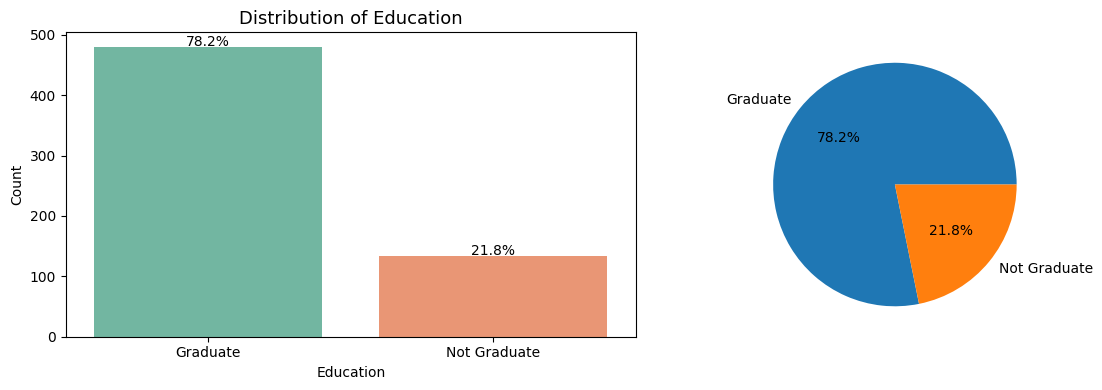

Feature: Self_Employed
****************************************
               Count  Percentage
Self_Employed                   
No               532       86.64
Yes               82       13.36



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


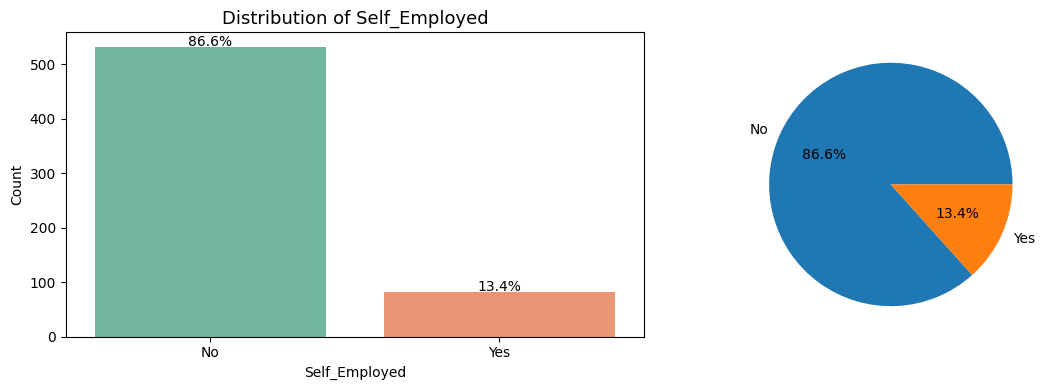

Feature: Property_Area
****************************************
               Count  Percentage
Property_Area                   
Semiurban        233       37.95
Urban            202       32.90
Rural            179       29.15



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


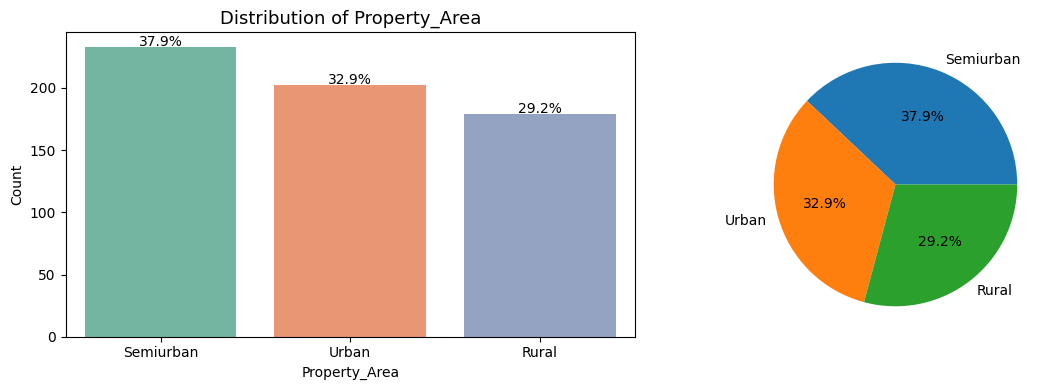

Feature: Loan_Status
****************************************
             Count  Percentage
Loan_Status                   
Y              422       68.73
N              192       31.27



C:\Users\ncc\AppData\Local\Temp\ipykernel_7604\3810989115.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=data, palette='Set2', order=freq.index,color='teal')


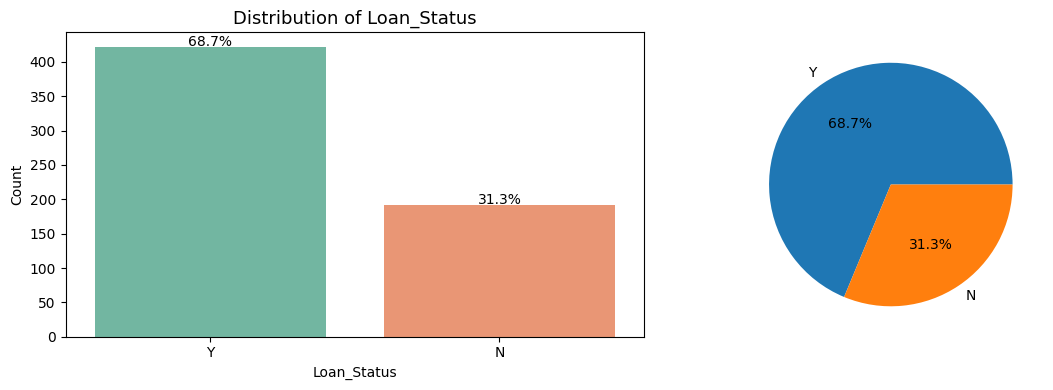

In [40]:
for col in categorical_columns:
    univariate_categorical_eda(data, col)

**Examine relationships between features and the target variable (loan approval status) using scatter plots, correlation matrices, and cross-tabulations.**

In [41]:
data.head(2)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N


In [ ]:
data.groupby("Dependents")["Education"]


**Identify trends, anomalies, and patterns that could impact loan outcomes.**

### **Reporting and Insights**

**Summarize key findings and insights derived from the EDA.**

**Create comprehensive visualizations and dashboards to communicate your insights effectively.**